# Lecture 9 - Genetic algorithms and the Traveling Salesman Problem


The traveling salesman problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

Consider now the ordered sequence of cities, $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, which goes from city 1 to the n$^{th}$ city. The path that minimizes the following loss/cost function:

$$
L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|^2
$$

or 
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$


(with $\vec{x}_{N+1}=\vec{x}_1$) is one particular permutation, P, of the ordered sequence of cities $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, i.e. 

$$
\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N = \vec{c}_{P1}, \vec{c}_{P2}, \dots, \vec{c}_{PN}
$$

Note also that any particular permutation of the ordered sequence of cities can be obtained from the combination of many simple permutations among pairs of cities.

We can express a possible path via a 1D vector whose elements, from the first to the last, are integers that represents the cities in the order in which the salesman would visit them; for example for $N=5$ cities one possible path is represented by the vector:

$$
\left[ 1, 3, 5, 4, 2 \right]
$$

**Alteratively**, we can express a possible path also via a configuration of a $N\times N$ 2D *Ising-like* model with the following bonds:
1. any row must have one and at most one up spin
2. any column must have one and at most one up spin,

all the other spins are down.

We can represent such a configuration with a $N\times N$ matrix whose elements are 1 (spin up) or 0 (spin down); for example, in the case of a TSP with 5 cities:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 1 & 0\\
0 & 0 & 1 & 0 & 0\\
\end{bmatrix}
$$

You can interpret this matrix in the following way:
- column index represents time of visit: first colum = first visit, etc.
- row index represents the ordered sequence of cities: first row = first city, etc.

the previous matrix thus refers to the following sequence:

$$
\vec{x}_1, \vec{x}_2, \vec{x}_3, \vec{x}_4, \vec{x}_5 = 
\vec{c}_{1}, \vec{c}_{3}, \vec{c}_{5}, \vec{c}_{4}, \vec{c}_{2}
$$

and thus to the following *cost* of the path:

$$
L^{(2)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3|^2 + |\vec{c}_3-\vec{c}_5|^2 + |\vec{c}_5-\vec{c}_4|^2 +
|\vec{c}_4-\vec{c}_2|^2 + |\vec{c}_2-\vec{c}_1|^2
$$

or
$$
L^{(1)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3| + |\vec{c}_3-\vec{c}_5| + |\vec{c}_5-\vec{c}_4| +
|\vec{c}_4-\vec{c}_2| + |\vec{c}_2-\vec{c}_1|
$$


Note that, for this *ising-like* representation any particular permutation of the ordered sequence of cities can be obtained by a sequence of multiple pair permutations among rows and/or among columns.

**Warm suggestion: by using the 1D representation** (but you can work with the representation you prefer or the one you are able to invent) ...

### Exercise 09.1

Write a code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.

You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population with $M$ individuals, e.g. select the individual $j$ with the algorithm: $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Set the first city to always appear at position 1, so as to reduce the degeneration of the shortest route to be 2, which corresponds to walking the shortest route in clockwise and anti-clockwise directions.

Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bonds and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 34 cities randomly placed **on** a circumference
- 34 cities randomly placed **inside** a square

Show your results via:

- a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm
- a picture of the best path in cartesian coordinates

## Exercise 9.1 - Solution 

This code implements a Genetic Algorithm (GA) to solve the Traveling Salesperson Problem (TSP). The primary objective is to find the shortest possible route that visits a set of $N$ cities exactly once and returns to the starting city. The code utilizes the Armadillo C++ library for efficient matrix operations and vector handling.

The simulation runs the optimization for two distinct spatial configurations of cities: a random distribution along a unit circumference and a uniform distribution inside a square.

### Core Architecture

The code is divided into three main components:

* **`main.cpp`**: Orchestrates the random number generator setup, defines the hyperparameters, and executes the simulation for both the circle and square city configurations.
* **`System` Class**: Manages the environment. It handles city generation, calculates the distance matrix, manages the population of candidate solutions, and controls the generational loop (selection, crossover, and succession).
* **`Individual` Class**: Represents a single candidate solution (a specific sequence of cities). It handles genome initialization, validity checking, fitness (path length) calculation, and genetic mutations.

---

### How the Algorithm Works

The algorithm follows the standard evolutionary steps of a Genetic Algorithm, customized for sequence-based optimization.

#### 1. Initialization
The system begins by placing 34 cities in the designated 2D space (circle or square). To optimize computational efficiency, it pre-calculates a distance matrix containing the Euclidean distances between all possible pairs of cities. 
An initial population of 200 `Individual` objects is generated. Each individual is given a random valid path, ensuring that the first city (index 0) remains fixed as the starting point to avoid degenerate, overlapping solutions.

#### 2. Fitness Evaluation
In this context, the "fitness" corresponds to the total length of the path. Because the goal is to minimize the path, a lower fitness value represents a better solution. The `compute_fitness` method calculates this by summing the distances between consecutive cities in the genome sequence, including the final return trip to the starting city.

#### 3. Selection
The population is sorted based on fitness, from best (shortest) to worst (longest). The algorithm uses a rank-based selection operator to choose parents for the next generation. It selects an individual's index from the sorted population using a biased formula: 
$index = \lfloor N_{pop} \times r^p \rfloor$
Here, $N_{pop}$ is the population size, $r$ is a random uniform variable where $r \in [0, 1)$, and $p$ is an exponent set to 3.0. This heavily skews the selection probability toward the fittest individuals while still leaving a small chance for less fit individuals to reproduce.

#### 4. Crossover (Recombination)
When two parents are selected, they have a 70% chance to undergo crossover to produce two children. The code implements an ordered crossover method to ensure valid sequences:
* A random cut-point is chosen in the genome.
* Child 1 inherits the exact sequence from Parent 1 up to the cut-point.
* The remaining empty spots in Child 1 are filled using the cities from Parent 2, strictly in the order they appear in Parent 2.
* Child 2 is created identically, swapping the roles of the parents.

#### 5. Mutations
To maintain genetic diversity and prevent the algorithm from getting stuck in local minima, each child has a 20% probability of undergoing one or more of the following structural mutations:
* **Pair Permutation:** Swaps the positions of two randomly chosen cities.
* **Shift:** Moves a contiguous block of $m$ cities forward by $n$ positions.
* **Contiguous Permutation:** Swaps the positions of two contiguous blocks of cities.
* **Inversion:** Reverses the sequence order of a randomly selected block of cities.

#### 6. Generational Update and Output
The newly created offspring entirely replace the old generation. After the population is updated and sorted, the algorithm records the loss (both the absolute best path length and the average of the top 50% of the population) to monitor convergence. This process loops for 600 generations. Finally, the coordinates of the best-found path are saved to external `.dat` files for visualization.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib.collections import LineCollection
plt.style.use('default')

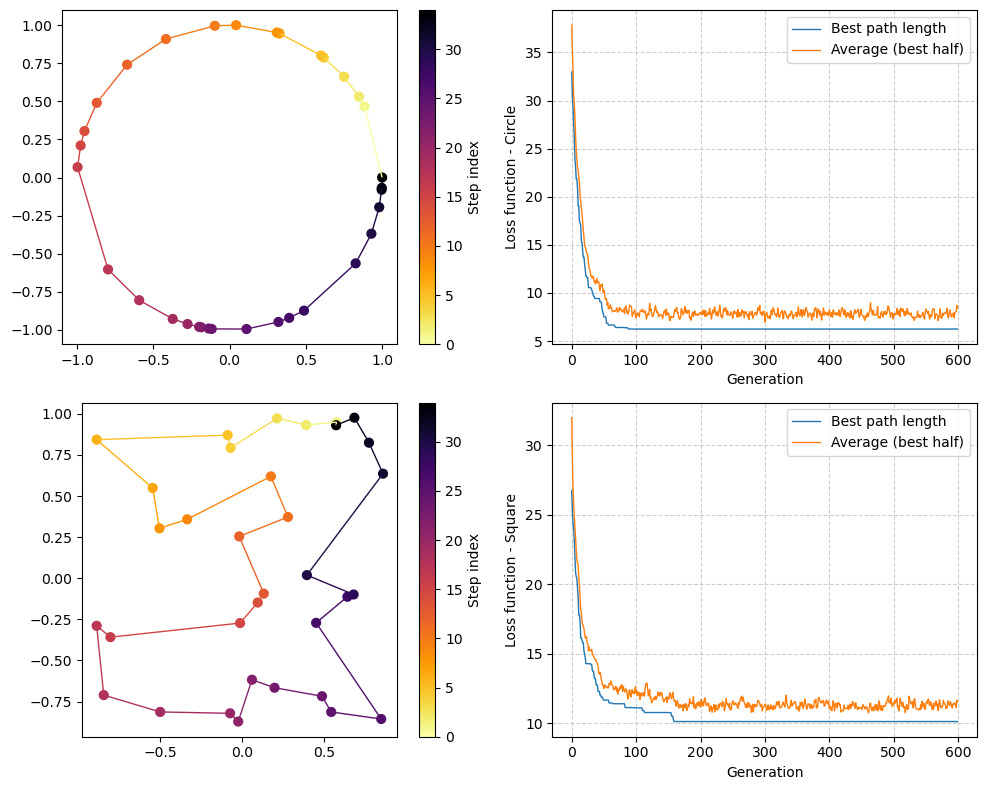

In [40]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

data = np.loadtxt("circle_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[0,0].add_collection(lc)

sc = axs[0,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[0,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[0,0], label="Step index") 

data = np.loadtxt("circle_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[0,1].plot(gen, best, label="Best path length", linewidth=1)
axs[0,1].plot(gen, avg, label="Average (best half)", linewidth=1)

axs[0,1].set_xlabel("Generation")
axs[0,1].set_ylabel("Loss function - Circle")
axs[0,1].legend()
axs[0,1].grid(True, linestyle='--', alpha=0.6)

data = np.loadtxt("square_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[1,0].add_collection(lc)

sc = axs[1,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[1,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[1,0], label="Step index")  

data = np.loadtxt("square_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[1,1].plot(gen, best, label="Best path length", linewidth=1)
axs[1,1].plot(gen, avg, label="Average (best half)", linewidth=1)

axs[1,1].set_xlabel("Generation")
axs[1,1].set_ylabel("Loss function - Square")
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()